In [69]:
#!/mrhome/amingk/anaconda3/envs/7tpd/bin/python
import numpy as np
import pandas as pd
import stan
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('/mrhome/amingk/Documents/7TPD/ActStimRL')
import arviz as az
from scipy.stats import gaussian_kde
from utils import *
import os
from scipy.stats import pearsonr
from scipy import stats

In [70]:
# full model name
model_full_name = 'indv_model2'
# main directory of individual model
main_indv_model_dir =f'{SCRATCH_INDV_MODEL_DIR}/{model_full_name}/'
# merge and save behavioral data with summary model of paramter
combine_parameter_highRewardChoice(main_indv_model_dir=main_indv_model_dir, param='weight', model=model_full_name)

In [71]:
# read behavioral data with summary paramter
df_beh_paramerer = pd.read_csv(PROJECT_NoNAN_BEH_REL_IRREL_HIGH_REWARD_OPTION_GROUPBY_ALL_FILE_MODEL_PARAMETER)

In [72]:
df_beh_paramerer.columns

Index(['group', 'patient', 'medication', 'sub_ID', 'block',
       'relevantHighRewardOption', 'irrelevantHighRewardOption',
       'relevantVrIrrelevantHighRewardOption', 'weight_parameter_mean',
       'weight_parameter_map'],
      dtype='object')

In [75]:
df_beh_paramerer_groupby = df_beh_paramerer.groupby(['patient', 'sub_ID', 'block'])[['relevantHighRewardOption', 'irrelevantHighRewardOption',
                                                                                     'relevantVrIrrelevantHighRewardOption', 'weight_parameter_mean',
                                                                                     'weight_parameter_map']].mean().reset_index()

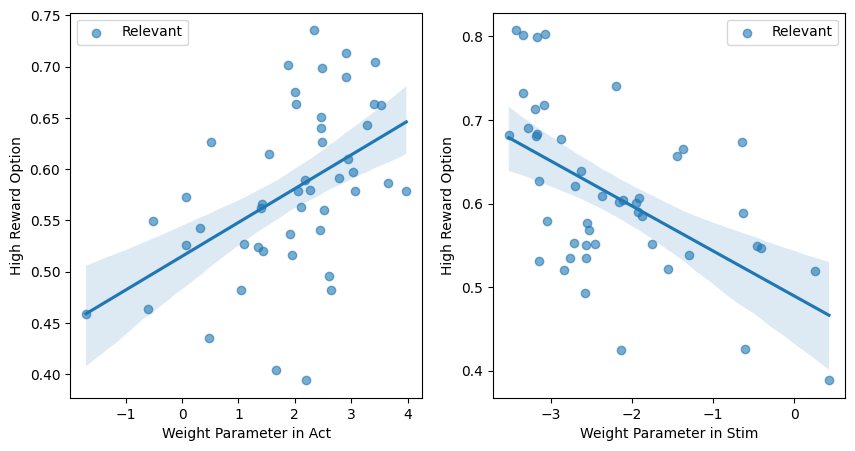

In [81]:

df_act = df_beh_paramerer_groupby[(df_beh_paramerer_groupby['block'] == 'Act')]
fig, ax = plt.subplots(nrows=1,ncols=2, figsize=(10,5))
ax=ax.flatten()
sns.regplot(data=df_act,x="weight_parameter_map",y="relevantHighRewardOption",
    ax=ax[0],label="Relevant",scatter_kws={"alpha": 0.6})

ax[0].legend()
ax[0].set_xlabel("Weight Parameter in Act")
ax[0].set_ylabel("High Reward Option")

df_stim = df_beh_paramerer_groupby[df_beh_paramerer_groupby['block'] == 'Stim']

sns.regplot(data=df_stim,x="weight_parameter_map",y="relevantHighRewardOption",
            ax=ax[1],label="Relevant",scatter_kws={"alpha": 0.6})

ax[1].legend()
ax[1].set_xlabel("Weight Parameter in Stim")
ax[1].set_ylabel("High Reward Option")

plt.show()

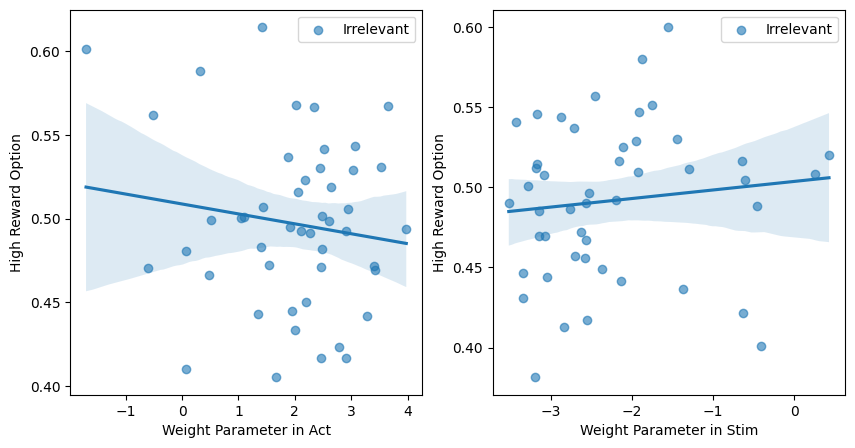

In [82]:

df_act = df_beh_paramerer_groupby[df_beh_paramerer_groupby['block'] == 'Act']
fig, ax = plt.subplots(nrows=1,ncols=2, figsize=(10,5))
ax=ax.flatten()

sns.regplot(data=df_act, x="weight_parameter_map", y="irrelevantHighRewardOption",
    ax=ax[0],label="Irrelevant",scatter_kws={"alpha": 0.6})
ax[0].legend()
ax[0].set_xlabel("Weight Parameter in Act")
ax[0].set_ylabel("High Reward Option")

df_stim = df_beh_paramerer_groupby[df_beh_paramerer_groupby['block'] == 'Stim']


sns.regplot(data=df_stim,x="weight_parameter_map",y="irrelevantHighRewardOption",
    ax=ax[1],label="Irrelevant",scatter_kws={"alpha": 0.6})
ax[1].legend()
ax[1].set_xlabel("Weight Parameter in Stim")
ax[1].set_ylabel("High Reward Option")

plt.show()

In [84]:
df_beh_paramerer_plot = df_beh_paramerer.copy()
#df_beh_paramerer_plot.loc[df_beh_paramerer_plot['block']=='Stim', 'weight_parameter'] = 1- df_beh_paramerer_plot[df_beh_paramerer_plot['block']=='Stim']['weight_parameter']

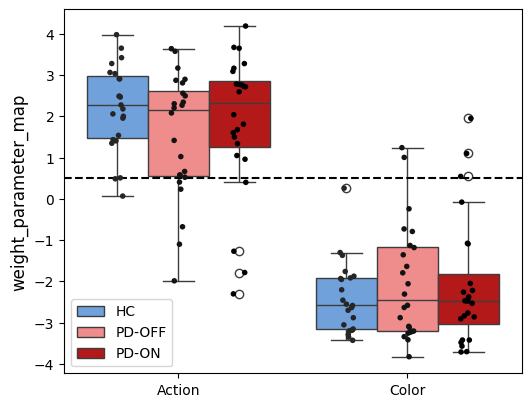

In [95]:
# Standardize group and condition labels
df_beh_paramerer_plot['group'] = df_beh_paramerer_plot['group'].replace([1,2,3], ['PD-OFF', 'HC', 'PD-ON'])
df_beh_paramerer_plot['Condition'] = df_beh_paramerer_plot['block'].replace(['Act', 'Stim'], ['Action', 'Color'])
group_order = ['HC', 'PD-OFF', 'PD-ON']
# Plot setting 
mm = 1/2.54  # convert cm to inches for figure size
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(15*mm, 12*mm))
#axs = axs.flatten()
    
# Custom color palette
custom_palette = {'HC': COLORS['HC'], 'PD-ON': COLORS['PD-ON'], 'PD-OFF': COLORS['PD-OFF']}

# relevant high Reward Option 
sns.boxplot(data=df_beh_paramerer_plot, x='Condition', y='weight_parameter_map', hue='group', ax=axs,
            palette=custom_palette, hue_order=group_order)
sns.stripplot(data=df_beh_paramerer_plot, x='Condition', y='weight_parameter_map', hue='group', ax=axs,
                dodge=True, alpha=1, size=4, legend=False, palette='dark:black', hue_order=group_order)
axs.set_ylabel('weight_parameter_map', fontsize=12)
axs.set_xlabel('', fontsize=12)
axs.axhline(.5, color='black', linestyle='--')
#axs.set_ylim(0,1)
axs.legend(fontsize=10, loc="lower left")
    


In [93]:
stats.ttest_ind(df_beh_paramerer_plot[(df_beh_paramerer_plot['block']=='Act')&(df_beh_paramerer_plot['patient']=='PD')&(df_beh_paramerer_plot['medication']=='OFF')]['weight_parameter_mean'],
                df_beh_paramerer_plot[(df_beh_paramerer_plot['block']=='Act')&(df_beh_paramerer_plot['patient']=='HC')]['weight_parameter_mean'])

TtestResult(statistic=-2.028849481587803, pvalue=0.048415096339053616, df=45.0)

In [170]:
#
x = df_beh_paramerer[df_beh_paramerer['block']=='Stim']["weight_parameter"]
y = df_beh_paramerer[df_beh_paramerer['block']=='Stim']["relevantVrIrrelevantHighRewardOption"]

r, p = pearsonr(x, y)

print(f"r = {r:.3f}, p = {p:.5f}")

r = -0.528, p = 0.00000


In [99]:
clinical_evaluation.columns

Index(['sub_ID', 'x_number', 'group', 'age', 'sex', 'disease_duration',
       'time_symptomns', 'most_affected_left_right_side_baselineUPDRS',
       'most_affected_left_right_side_UPDRSOFF',
       'most_affected_left_right_side_UPDRSON',
       'systolic_blood_pressure_baselineUPDRS', 'total_BaselineUPDRS',
       'total_UPDRSOFF', 'total_UPDRSON', 'NMSS', 'MoCA', 'BDI', 'LARS'],
      dtype='object')

In [106]:
# Read clinical data
clinical_evaluation = pd.read_csv(f'{PROJECT_CLIN_EVAL_FILE}')
clinical_evaluation_PD = clinical_evaluation[clinical_evaluation['group'] == 'PD']
clinical_evaluation_HC = clinical_evaluation[clinical_evaluation['group'] == 'HC']

# Filter behavioral data
df_PD_Act_OFF = df_beh_paramerer[(df_beh_paramerer['patient'] == 'PD') &
                                 (df_beh_paramerer['block'] == 'Act') &
                                 (df_beh_paramerer['medication'] == 'OFF')]

df_PD_Stim_OFF = df_beh_paramerer[(df_beh_paramerer['patient'] == 'PD') &
                                 (df_beh_paramerer['block'] == 'Stim') &
                                 (df_beh_paramerer['medication'] == 'OFF')]

df_PD_Act_ON = df_beh_paramerer[(df_beh_paramerer['patient'] == 'PD') &
                                (df_beh_paramerer['block'] == 'Act') &
                                (df_beh_paramerer['medication'] == 'ON')]
df_PD_Stim_ON = df_beh_paramerer[(df_beh_paramerer['patient'] == 'PD') &
                                (df_beh_paramerer['block'] == 'Act') &
                                (df_beh_paramerer['medication'] == 'ON')]

df_HC_Act = df_beh_paramerer[(df_beh_paramerer['patient'] == 'HC') &
                                 (df_beh_paramerer['block'] == 'Act')]

df_HC_Stim = df_beh_paramerer[(df_beh_paramerer['patient'] == 'HC') &
                                 (df_beh_paramerer['block'] == 'Stim')]

# Merge
merged_HC_Act = pd.merge(df_HC_Act, clinical_evaluation_HC, on='sub_ID', how='inner')
merged_HC_Stim = pd.merge(df_HC_Stim, clinical_evaluation_HC, on='sub_ID', how='inner')
merged_PD_Act_OFF = pd.merge(df_PD_Act_OFF, clinical_evaluation_PD, on='sub_ID', how='inner')
merged_PD_Stim_OFF = pd.merge(df_PD_Stim_OFF, clinical_evaluation_PD, on='sub_ID', how='inner')
merged_PD_Act_ON = pd.merge(df_PD_Act_ON, clinical_evaluation_PD, on='sub_ID', how='inner')
merged_PD_Stim_ON = pd.merge(df_PD_Stim_ON, clinical_evaluation_PD, on='sub_ID', how='inner')

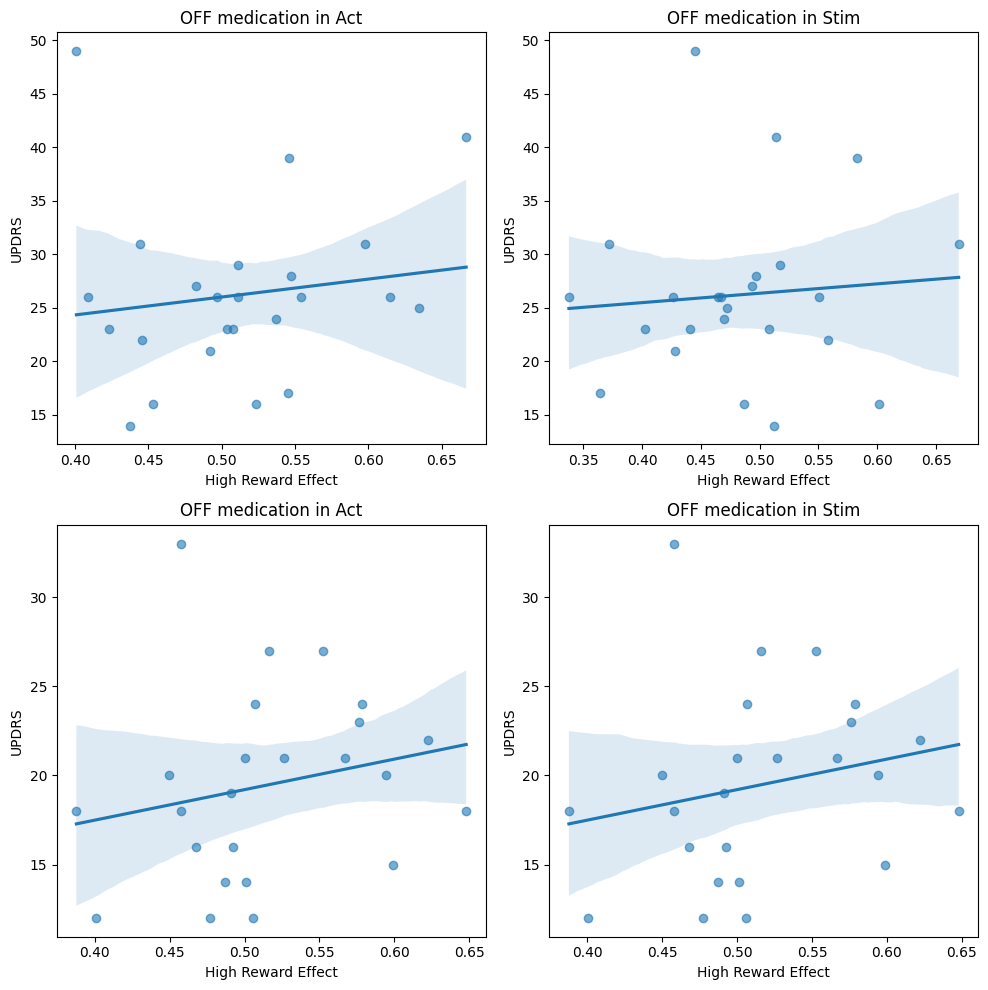

In [133]:
# Plot
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax=ax.flatten()
sns.regplot(data=merged_PD_Act_OFF,x="irrelevantHighRewardOption",y="total_UPDRSOFF",
            ax=ax[0],scatter_kws={"alpha": 0.6})
ax[0].set_title("OFF medication in Act")
ax[0].set_xlabel("High Reward Effect")
ax[0].set_ylabel("UPDRS")

sns.regplot(data=merged_PD_Stim_OFF,x="irrelevantHighRewardOption",y="total_UPDRSOFF",
            ax=ax[1],scatter_kws={"alpha": 0.6})
ax[1].set_title("OFF medication in Stim")
ax[1].set_xlabel("High Reward Effect")
ax[1].set_ylabel("UPDRS")


sns.regplot(data=merged_PD_Act_ON,x="irrelevantHighRewardOption",y="total_UPDRSON",
            ax=ax[2],scatter_kws={"alpha": 0.6})
ax[2].set_title("OFF medication in Act")
ax[2].set_xlabel("High Reward Effect")
ax[2].set_ylabel("UPDRS")

sns.regplot(data=merged_PD_Stim_ON,x="irrelevantHighRewardOption",y="total_UPDRSON",
            ax=ax[3],scatter_kws={"alpha": 0.6})
ax[3].set_title("OFF medication in Stim")
ax[3].set_xlabel("High Reward Effect")
ax[3].set_ylabel("UPDRS")

plt.tight_layout()
plt.show()

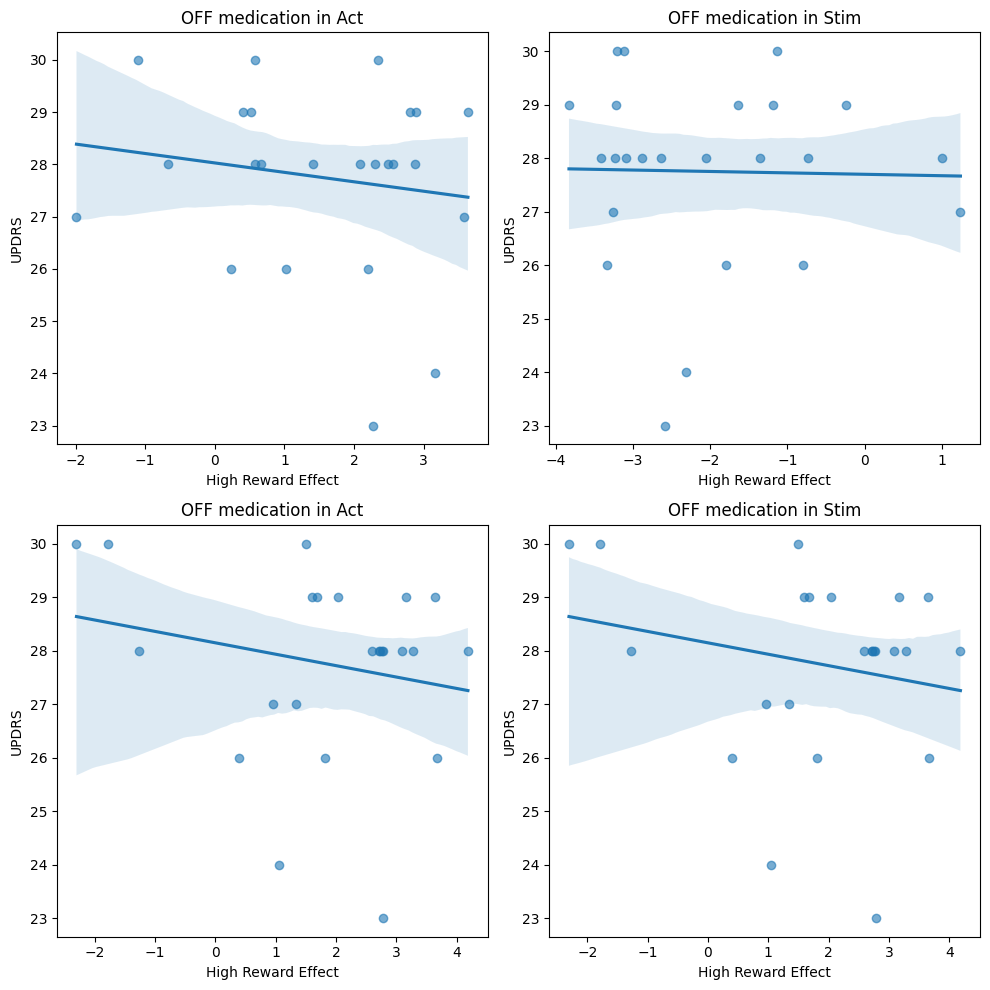

In [131]:
# Plot
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax=ax.flatten()
sns.regplot(data=merged_PD_Act_OFF,x="weight_parameter_map",y="MoCA",
            ax=ax[0],scatter_kws={"alpha": 0.6})
ax[0].set_title("OFF medication in Act")
ax[0].set_xlabel("High Reward Effect")
ax[0].set_ylabel("UPDRS")

sns.regplot(data=merged_PD_Stim_OFF,x="weight_parameter_map",y="MoCA",
            ax=ax[1],scatter_kws={"alpha": 0.6})
ax[1].set_title("OFF medication in Stim")
ax[1].set_xlabel("High Reward Effect")
ax[1].set_ylabel("UPDRS")


sns.regplot(data=merged_PD_Act_ON,x="weight_parameter_map",y="MoCA",
            ax=ax[2],scatter_kws={"alpha": 0.6})
ax[2].set_title("OFF medication in Act")
ax[2].set_xlabel("High Reward Effect")
ax[2].set_ylabel("UPDRS")

sns.regplot(data=merged_PD_Stim_ON,x="weight_parameter_map",y="MoCA",
            ax=ax[3],scatter_kws={"alpha": 0.6})
ax[3].set_title("OFF medication in Stim")
ax[3].set_xlabel("High Reward Effect")
ax[3].set_ylabel("UPDRS")

plt.tight_layout()
plt.show()

In [114]:
merged_PD_Act_OFF

,group_x,patient,medication,sub_ID,block,relevantHighRewardOption,irrelevantHighRewardOption,relevantVrIrrelevantHighRewardOption,weight_parameter_mean,weight_parameter_map,...,most_affected_left_right_side_UPDRSOFF,most_affected_left_right_side_UPDRSON,systolic_blood_pressure_baselineUPDRS,total_BaselineUPDRS,total_UPDRSOFF,total_UPDRSON,NMSS,MoCA,BDI,LARS
0,1,PD,OFF,sub-004,Act,0.470968,0.615054,-0.144086,3.213597,2.267463,...,-16.0,-13.0,3.0,22.0,26.0,16.0,31.0,23.0,14.00000,-32.0
1,1,PD,OFF,sub-005,Act,0.358009,0.400866,-0.042857,3.616945,2.807859,...,7.0,5.0,22.0,33.0,49.0,21.0,14.0,29.0,9.00000,-32.0
2,1,PD,OFF,sub-010,Act,0.417749,0.597403,-0.179654,0.365974,0.232637,...,17.0,14.0,22.0,33.0,31.0,24.0,24.0,26.0,2.00000,-28.0
3,1,PD,OFF,sub-025,Act,0.463112,0.507841,-0.044728,4.019042,3.573615,...,10.0,8.0,19.0,27.0,23.0,27.0,6.0,27.0,2.00000,-14.0
4,1,PD,OFF,sub-029,Act,0.479114,0.554285,-0.075171,-2.019155,-1.101116,...,-13.0,-7.0,19.0,22.0,26.0,18.0,34.0,30.0,2.00000,-21.0
5,1,PD,OFF,sub-040,Act,0.495992,0.496433,-0.000441,3.250304,2.493863,...,-5.0,-4.0,18.0,38.0,26.0,14.0,26.0,28.0,11.00000,-24.0
6,1,PD,OFF,sub-041,Act,0.604040,0.547475,0.056566,0.951301,0.662294,...,-17.0,-14.0,30.0,32.0,28.0,21.0,62.0,28.0,9.00000,-22.0
7,1,PD,OFF,sub-042,Act,0.524492,0.545998,-0.021505,3.740135,2.871552,...,9.0,8.0,13.0,36.0,39.0,27.0,34.0,28.0,12.00000,-28.0
8,1,PD,OFF,sub-045,Act,0.730270,0.437255,0.293015,4.304010,3.637072,...,12.0,10.0,11.0,11.0,14.0,12.0,3.0,29.0,0.00000,-26.0
9,1,PD,OFF,sub-052,Act,0.483289,0.453264,0.030025,0.178139,0.572848,...,-13.0,-11.0,18.0,28.0,16.0,14.0,13.0,30.0,3.00000,-28.0


In [113]:
#
x = merged_PD_Act_OFF["irrelevantHighRewardOption"]
y = merged_PD_Act_OFF["total_UPDRSOFF"]

r, p = pearsonr(x, y)

print(f"r = {r:.3f}, p = {p:.5f}")

r = 0.146, p = 0.49469
